In [1]:
import numpy as np
import pandas as pd
'''
Whether the error terms are mean zero?
Whether the error terms have constant variance?
Whether the error terms are normally distributed?
Whether there is influential point in the data?
'''

'\nWhether the error terms are mean zero?\nWhether the error terms have constant variance?\nWhether the error terms are normally distributed?\nWhether there is influential point in the data?\n'

In [2]:
df = pd.read_csv('Dataset1.csv') #讀取dataset1

In [3]:
df

,Unnamed: 0,y,x1,x2
0,1,0.982247,8.085504,7.553536
1,2,7.859147,3.097235,4.949049
2,3,-4.947182,5.987528,6.181940
3,4,-1.667653,9.990765,2.360591
4,5,-3.161624,5.352071,6.718903
...,...,...,...,...
95,96,-4.320759,4.489420,9.020733
96,97,11.890181,0.673097,7.592682
97,98,11.589620,1.105707,6.878812
98,99,-4.403614,8.881647,1.671280


In [4]:
df.drop(columns = df.columns[0], axis = 1, inplace= True)  #drop第一行

In [5]:
df

,y,x1,x2
0,0.982247,8.085504,7.553536
1,7.859147,3.097235,4.949049
2,-4.947182,5.987528,6.181940
3,-1.667653,9.990765,2.360591
4,-3.161624,5.352071,6.718903
...,...,...,...
95,-4.320759,4.489420,9.020733
96,11.890181,0.673097,7.592682
97,11.589620,1.105707,6.878812
98,-4.403614,8.881647,1.671280


In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
  

# set x , y
X = df[['x1','x2']]   
y = df['y']   

X = sm.add_constant(X) # add constant

# fitting model - OLS linear regression
reg = sm.OLS(y, X).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     28.42
Date:                Thu, 03 Nov 2022   Prob (F-statistic):           1.93e-10
Time:                        00:25:48   Log-Likelihood:                -300.86
No. Observations:                 100   AIC:                             607.7
Df Residuals:                      97   BIC:                             615.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.6072      1.356      6.348      0.000       5.916      11.298
x1            -1.2266      0.165     -7.427      0.000      -1.554      -0.899
x2             0.0634      0.158      0.402      0.689      -0.250       0.377
==============================================================================
Omnibus:                        2.856   Durbin-Watson:                   2.255
Prob(Omnibus):                  0.240   Jarque-Bera (JB):                2.691
Skew:                           0.329   Prob(JB):                        0.260
Kurtosis:                       2.539   Cond. No.                         21.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
from bioinfokit.visuz import stat
df[['yhat']]=pd.DataFrame(reg.predict(X)) #給定x1,x2，算出回歸線上 y_hat
df['res']=pd.DataFrame(reg.resid) #實際y - y_hat 求出殘差
df['std_res']=reg.get_influence().resid_studentized_internal #計算studentize res
df.head(2)

,y,x1,x2,yhat,res,std_res
0,0.982247,8.085504,7.553536,-0.831213,1.813460,0.369212
1,7.859147,3.097235,4.949049,5.122164,2.736983,0.554174


In [8]:
# 輸出 fitted (y_hat) vs residuals plot 殘差圖。
stat.reg_resid_plot(df=df, yhat='yhat', resid='res', stdresid='std_res')

In [9]:
# Mean 趨近於0
Mean = sum(df['res'])/len(df['res'])
Mean

3.3573144264664732e-15

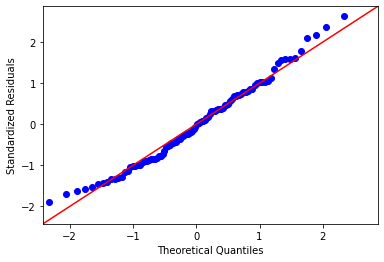

In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 劃出qq- plot，residual符合常態分佈
sm.qqplot(df['std_res'], line='45')
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

In [11]:
influence = reg.get_influence()
inf_sum = influence.summary_frame()
inf_sum

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.030322,0.038083,0.032515,0.001222,0.369212,0.026180,0.060536,0.367562,0.060266
1,0.051607,-0.040683,-0.008376,0.001600,0.554174,0.015386,0.069274,0.552185,0.069026
2,0.003013,-0.037000,-0.047829,0.007091,-1.334392,0.011807,-0.145856,-1.339851,-0.146453
3,-0.005734,0.055555,-0.026652,0.001903,0.375062,0.039009,0.075566,0.373395,0.075230
4,-0.001485,-0.009631,-0.057384,0.005471,-1.138338,0.012508,-0.128113,-1.140096,-0.128311
...,...,...,...,...,...,...,...,...,...
95,0.046005,0.019167,-0.198805,0.022602,-1.626467,0.024991,-0.260397,-1.640587,-0.262658
96,0.070490,-0.108322,0.044720,0.006964,0.742361,0.036523,0.144537,0.740631,0.144200
97,0.079489,-0.106446,0.030927,0.006616,0.796182,0.030358,0.140878,0.794668,0.140610
98,-0.011978,-0.048973,0.044270,0.002373,-0.454199,0.033359,-0.084376,-0.452333,-0.084030


In [12]:
inf_sum[inf_sum['cooks_d'] >1] # no obs cooks distance > 1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits


In [13]:
d = 2 / (100**0.5)

In [14]:
inf_sum[abs(inf_sum['dfb_x1']) > d] # these obs infulenced to b1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
15,-0.293134,0.358460,0.243347,0.070760,2.177399,0.042856,0.460740,2.221107,0.469989
37,-0.225517,0.222497,0.237905,0.039959,1.592025,0.045161,0.346231,1.604903,0.349032
39,-0.162724,0.247665,0.104666,0.030577,1.573963,0.035706,0.302873,1.586216,0.305230
48,-0.349148,0.451879,0.268301,0.102714,2.642309,0.042270,0.555106,2.728689,0.573253
61,-0.216864,0.280288,0.173661,0.043124,1.782844,0.039110,0.359684,1.803424,0.363836
65,-0.336926,0.304565,0.370114,0.081787,2.108773,0.052290,0.495340,2.147682,0.504479
72,-0.417759,0.309818,0.263536,0.057492,-1.579812,0.064640,-0.415304,-1.592266,-0.418577
74,-0.392479,0.361491,0.419484,0.106863,2.369350,0.054022,0.566207,2.428424,0.580324


In [15]:
inf_sum[abs(inf_sum['dfb_x2']) > d] # these obs infulenced to b2

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
15,-0.293134,0.358460,0.243347,0.070760,2.177399,0.042856,0.460740,2.221107,0.469989
27,0.031001,0.069848,-0.233630,0.031020,-1.707481,0.030932,-0.305056,-1.724774,-0.308146
37,-0.225517,0.222497,0.237905,0.039959,1.592025,0.045161,0.346231,1.604903,0.349032
45,0.255614,-0.090552,-0.228638,0.027290,1.600743,0.030962,0.286130,1.613930,0.288487
48,-0.349148,0.451879,0.268301,0.102714,2.642309,0.042270,0.555106,2.728689,0.573253
55,0.241312,-0.059657,-0.244331,0.027700,1.496874,0.035761,0.288271,1.506641,0.290151
65,-0.336926,0.304565,0.370114,0.081787,2.108773,0.052290,0.495340,2.147682,0.504479
66,0.083230,-0.013500,-0.243265,0.031559,-1.895072,0.025685,-0.307694,-1.921178,-0.311933
72,-0.417759,0.309818,0.263536,0.057492,-1.579812,0.064640,-0.415304,-1.592266,-0.418577
74,-0.392479,0.361491,0.419484,0.106863,2.369350,0.054022,0.566207,2.428424,0.580324


In [16]:
# ====================dataset2 =======================================

In [17]:
df2 = pd.read_csv('Dataset2.csv')

In [18]:
df2

,Unnamed: 0,y,x1,x2
0,1,1.951457,1.710472,9.108850
1,2,1.294728,7.642979,4.760867
2,3,3.798158,4.081358,8.867629
3,4,6.107192,8.827481,4.550966
4,5,1.836209,0.824636,5.919755
...,...,...,...,...
95,96,6.582407,8.937535,7.177878
96,97,10.170548,8.869408,2.221128
97,98,13.064182,9.530111,5.211532
98,99,11.957484,6.717786,3.598072


In [19]:
df2.drop(columns = df2.columns[0], axis = 1, inplace= True)

In [20]:
# fit multi linear regression model
X = df2[['x1','x2']]   # independent variables
y = df2['y']   # dependent variables

# to get intercept -- this is optional
X = sm.add_constant(X)

# fit the regression model
reg2 = sm.OLS(y, X).fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     8.658
Date:                Thu, 03 Nov 2022   Prob (F-statistic):           0.000347
Time:                        00:25:49   Log-Likelihood:                -257.51
No. Observations:                 100   AIC:                             521.0
Df Residuals:                      97   BIC:                             528.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6516      0.913      0.714      0.477      -1.161       2.464
x1             0.4800      0.117      4.114      0.000       0.248       0.712
x2             0.1235      0.115      1.078      0.284      -0.104       0.351
==============================================================================
Omnibus:                        6.085   Durbin-Watson:                   2.092
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                8.003
Skew:                          -0.247   Prob(JB):                       0.0183
Kurtosis:                       4.295   Cond. No.                         21.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
df2[['yhat']]=pd.DataFrame(reg2.predict(X)) 
df2['res']=pd.DataFrame(reg2.resid)
df2['std_res']=reg2.get_influence().resid_studentized_internal
df2.head(2)

,y,x1,x2,yhat,res,std_res
0,1.951457,1.710472,9.108850,2.597629,-0.646172,-0.204602
1,1.294728,7.642979,4.760867,4.908061,-3.613334,-1.130768


In [22]:
stat.reg_resid_plot(df=df2, yhat='yhat', resid='res', stdresid='std_res')

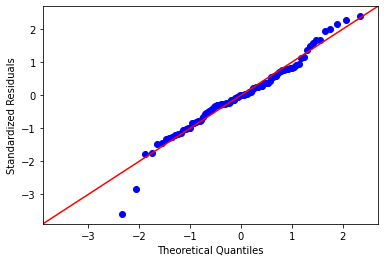

In [23]:
# line=45 option to plot the data around 45 degree line
sm.qqplot(df2['std_res'], line='45')
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

In [24]:
influence2 = reg2.get_influence()
inf_sum2 = influence2.summary_frame()
inf_sum2

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.003382,0.021144,-0.028075,0.000611,-0.204602,0.041974,-0.042826,-0.203589,-0.042614
1,0.032256,-0.109558,-0.004895,0.008353,-1.130768,0.019220,-0.158296,-1.132413,-0.158526
2,-0.001120,-0.000495,0.003987,0.000009,0.029057,0.029493,0.005065,0.028906,0.005039
3,-0.011099,0.028743,0.000325,0.000427,0.206507,0.029184,0.035805,0.205485,0.035628
4,0.002148,-0.002685,0.000334,0.000004,0.018160,0.032568,0.003332,0.018066,0.003315
...,...,...,...,...,...,...,...,...,...
95,-0.029163,0.036845,0.023080,0.000778,0.238572,0.039372,0.048299,0.237408,0.048063
96,0.004540,0.210427,-0.130925,0.031004,1.574467,0.036164,0.304977,1.586737,0.307354
97,-0.206787,0.392809,0.065914,0.067257,2.272914,0.037589,0.449191,2.323899,0.459267
98,0.058772,0.142484,-0.100360,0.030033,2.385564,0.015585,0.300166,2.446074,0.307780


In [25]:
inf_sum2[inf_sum2['cooks_d'] >1] # no obs cooks distance > 1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits


In [26]:
inf_sum2[abs(inf_sum2['dfb_x1']) > d] # these obs infulenced to b1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
42,0.391859,-0.200720,-0.649280,0.172716,-3.589292,0.038664,-0.719826,-3.834445,-0.768991
46,-0.213021,0.273006,0.162429,0.039962,1.679145,0.040786,0.346247,1.695288,0.349576
53,0.243693,-0.247123,-0.242475,0.045806,-1.743491,0.043251,-0.370698,-1.762314,-0.374700
87,0.277109,-0.232904,-0.378137,0.083076,-2.826066,0.030261,-0.499226,-2.934880,-0.518448
96,0.004540,0.210427,-0.130925,0.031004,1.574467,0.036164,0.304977,1.586737,0.307354
97,-0.206787,0.392809,0.065914,0.067257,2.272914,0.037589,0.449191,2.323899,0.459267


In [27]:
inf_sum2[abs(inf_sum2['dfb_x2']) > d] # # these obs are infulenced to b2

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
42,0.391859,-0.200720,-0.649280,0.172716,-3.589292,0.038664,-0.719826,-3.834445,-0.768991
53,0.243693,-0.247123,-0.242475,0.045806,-1.743491,0.043251,-0.370698,-1.762314,-0.374700
59,0.199375,0.132944,-0.338795,0.060630,2.011840,0.043006,0.426484,2.044554,0.433419
87,0.277109,-0.232904,-0.378137,0.083076,-2.826066,0.030261,-0.499226,-2.934880,-0.518448


In [28]:
# ====================dataset3 =======================================

In [29]:
df3 = pd.read_csv('Dataset3.csv')

In [30]:
df3

,Unnamed: 0,y,x1,x2
0,1,5.292686,7.572356,6.705634
1,2,3.862242,6.718456,1.822852
2,3,2.343725,0.456162,9.807907
3,4,2.523175,3.271902,3.950201
4,5,1.006730,1.176526,1.183439
...,...,...,...,...
95,96,3.122172,2.619427,9.091742
96,97,6.286796,8.409908,9.775787
97,98,1.812090,1.710308,4.605494
98,99,1.912983,3.138661,0.830161


In [31]:
df3.drop(columns = df3.columns[0], axis = 1, inplace= True)

In [32]:
df3

,y,x1,x2
0,5.292686,7.572356,6.705634
1,3.862242,6.718456,1.822852
2,2.343725,0.456162,9.807907
3,2.523175,3.271902,3.950201
4,1.006730,1.176526,1.183439
...,...,...,...
95,3.122172,2.619427,9.091742
96,6.286796,8.409908,9.775787
97,1.812090,1.710308,4.605494
98,1.912983,3.138661,0.830161


In [33]:
# fit multi linear regression model
X = df3[['x1','x2']]   # independent variables
y = df3['y']   # dependent variables

# to get intercept -- this is optional
X = sm.add_constant(X)

# fit the regression model
reg3 = sm.OLS(y, X).fit()
reg3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     648.8
Date:                Thu, 03 Nov 2022   Prob (F-statistic):           7.14e-57
Time:                        00:25:50   Log-Likelihood:                -64.697
No. Observations:                 100   AIC:                             135.4
Df Residuals:                      97   BIC:                             143.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0528      0.114      0.464      0.643      -0.173       0.279
x1             0.5039      0.016     32.271      0.000       0.473       0.535
x2             0.2183      0.015     14.300      0.000       0.188       0.249
==============================================================================
Omnibus:                      116.889   Durbin-Watson:                   2.227
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2217.133
Skew:                           3.911   Prob(JB):                         0.00
Kurtosis:                      24.701   Cond. No.                         18.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
df3[['yhat']]=pd.DataFrame(reg3.predict(X)) 
df3['res']=pd.DataFrame(reg3.resid)
df3['std_res']=reg3.get_influence().resid_studentized_internal
df3.head(2)

,y,x1,x2,yhat,res,std_res
0,5.292686,7.572356,6.705634,5.332263,-0.039577,-0.085250
1,3.862242,6.718456,1.822852,3.836122,0.026120,0.056338


In [35]:
stat.reg_resid_plot(df=df3, yhat='yhat', resid='res', stdresid='std_res')

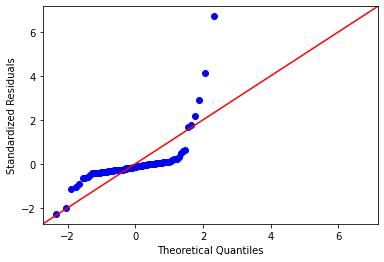

In [36]:
# line=45 option to plot the data around 45 degree line
sm.qqplot(df3['std_res'], line='45')
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

In [37]:
influence3 = reg3.get_influence()
inf_sum3 = influence3.summary_frame()
inf_sum3

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.004537,-0.007260,-0.004890,5.186659e-05,-0.085250,0.020961,-0.012474,-0.084813,-0.012410
1,0.003536,0.003662,-0.005691,2.556600e-05,0.056338,0.023594,0.008758,0.056048,0.008713
2,-0.006826,0.028408,-0.030742,6.704769e-04,-0.175769,0.061126,-0.044849,-0.174888,-0.044624
3,-0.008198,0.004694,0.002195,3.511166e-05,-0.087173,0.013672,-0.010263,-0.086726,-0.010211
4,0.043875,-0.026909,-0.025260,6.564302e-04,0.223264,0.038005,0.044377,0.222168,0.044159
...,...,...,...,...,...,...,...,...,...
95,-0.002969,0.043626,-0.074247,3.286176e-03,-0.510658,0.036428,-0.099290,-0.508703,-0.098910
96,0.040430,-0.032924,-0.047681,1.504505e-03,-0.300701,0.047544,-0.067183,-0.299286,-0.066867
97,-0.026722,0.024977,0.000259,3.948140e-04,-0.232408,0.021458,-0.034416,-0.231271,-0.034247
98,0.033780,-0.011259,-0.026907,4.503791e-04,0.210727,0.029528,0.036758,0.209686,0.036576


In [38]:
inf_sum3[inf_sum3['cooks_d'] >1] # no obs cooks distance > 1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits


In [39]:
inf_sum3[abs(inf_sum3['dfb_x1']) >d] # 

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
20,0.054931,-0.215945,0.285289,0.055342,2.171479,0.034013,0.407465,2.214759,0.415586
34,0.500810,-0.759406,0.317288,0.240968,4.147582,0.040329,0.850237,4.549208,0.932568
65,0.073224,0.480746,-0.418199,0.148494,2.918022,0.049717,0.667445,3.039408,0.695209
88,-0.804505,0.672531,1.132649,0.483281,6.710080,0.031196,1.204095,9.119412,1.636439


In [40]:
inf_sum3[abs(inf_sum3['dfb_x2']) >d] # 

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
8,-0.186426,-0.099387,0.242380,0.038825,-2.278368,0.021946,-0.341285,-2.329790,-0.348988
20,0.054931,-0.215945,0.285289,0.055342,2.171479,0.034013,0.407465,2.214759,0.415586
34,0.500810,-0.759406,0.317288,0.240968,4.147582,0.040329,0.850237,4.549208,0.932568
65,0.073224,0.480746,-0.418199,0.148494,2.918022,0.049717,0.667445,3.039408,0.695209
88,-0.804505,0.672531,1.132649,0.483281,6.710080,0.031196,1.204095,9.119412,1.636439


In [41]:
# ====================dataset4 =======================================

In [42]:
df4 = pd.read_csv('Dataset4.csv')

In [43]:
df4.drop(columns = df4.columns[0], axis = 1, inplace= True)

In [44]:
# fit multi linear regression model
X = df4[['x1','x2']]   # independent variables
y = df4['y']   # dependent variables

# to get intercept -- this is optional
X = sm.add_constant(X)

# fit the regression model
reg4 = sm.OLS(y, X).fit()
reg4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2428.
Date:                Thu, 03 Nov 2022   Prob (F-statistic):           3.27e-84
Time:                        00:25:50   Log-Likelihood:                -138.96
No. Observations:                 101   AIC:                             283.9
Df Residuals:                      98   BIC:                             291.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1267      0.113      1.120      0.265      -0.098       0.351
x1             0.5082      0.028     17.876      0.000       0.452       0.565
x2             0.1860      0.029      6.524      0.000       0.129       0.243
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.089
Skew:                          -0.050   Prob(JB):                        0.957
Kurtosis:                       2.894   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
df4[['yhat']]=pd.DataFrame(reg4.predict(X)) 
df4['res']=pd.DataFrame(reg4.resid)
df4['std_res']=reg4.get_influence().resid_studentized_internal
df4.head(2)

,y,x1,x2,yhat,res,std_res
0,0.969260,0.0,5.418240,1.134511,-0.165250,-0.173078
1,-1.600408,0.1,0.686234,0.305166,-1.905574,-1.973011


In [46]:
stat.reg_resid_plot(df=df4, yhat='yhat', resid='res', stdresid='std_res')

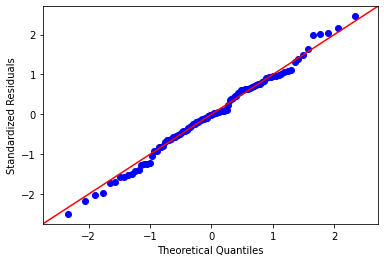

In [47]:
# line=45 option to plot the data around 45 degree line
sm.qqplot(df4['std_res'], line='45')
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

In [48]:
influence4 = reg4.get_influence()
inf_sum4 = influence4.summary_frame()
inf_sum4

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.018192,0.028238,-0.026244,0.000371,-0.173078,0.035840,-0.033370,-0.172219,-0.033204
1,-0.230795,0.056243,-0.016408,0.017620,-1.973011,0.013397,-0.229911,-2.003106,-0.233418
2,0.011230,-0.017749,0.016593,0.000146,0.108065,0.036168,0.020934,0.107518,0.020828
3,-0.104423,0.036479,-0.019513,0.003902,-0.923530,0.013539,-0.108194,-0.922831,-0.108112
4,0.012138,-0.014830,0.013425,0.000120,0.115339,0.026311,0.018960,0.114757,0.018864
...,...,...,...,...,...,...,...,...,...
96,0.029590,0.035108,-0.031738,0.000980,0.408961,0.017277,0.054226,0.407217,0.053995
97,0.074878,0.166423,-0.163936,0.012373,0.926990,0.041408,0.192665,0.926319,0.192525
98,-0.046275,-0.056394,0.050610,0.002490,-0.647670,0.017499,-0.086435,-0.645740,-0.086178
99,-0.112065,-0.352966,0.356737,0.048665,-1.240115,0.086702,-0.382093,-1.243567,-0.383157


In [49]:
inf_sum4[inf_sum4['cooks_d'] >1] # no obs cooks distance > 1

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
100,3.100885,-1.196398,-1.336782,17.182561,-1.683783,0.947867,-7.179671,-1.69994,-7.248566


In [50]:
d = 2 / (101**0.5)
inf_sum4[abs(inf_sum4['dfb_x1']) >d] # 

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
13,0.258143,-0.274414,0.248780,0.044380,2.458316,0.021556,0.364884,2.524828,0.374757
37,0.113278,-0.209586,0.212350,0.021175,1.320374,0.035156,0.252040,1.325463,0.253011
58,0.169070,-0.252827,0.268702,0.038889,2.156024,0.024484,0.341567,2.197752,0.348178
87,0.186359,0.478420,-0.487985,0.092091,1.991416,0.065128,0.525616,2.022576,0.533840
91,-0.167889,-0.311986,0.307449,0.046008,-2.027231,0.032494,-0.371516,-2.060528,-0.377618
99,-0.112065,-0.352966,0.356737,0.048665,-1.240115,0.086702,-0.382093,-1.243567,-0.383157
100,3.100885,-1.196398,-1.336782,17.182561,-1.683783,0.947867,-7.179671,-1.699940,-7.248566


In [51]:
inf_sum4[abs(inf_sum4['dfb_x2']) >d] # 

,dfb_const,dfb_x1,dfb_x2,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
13,0.258143,-0.274414,0.248780,0.044380,2.458316,0.021556,0.364884,2.524828,0.374757
37,0.113278,-0.209586,0.212350,0.021175,1.320374,0.035156,0.252040,1.325463,0.253011
58,0.169070,-0.252827,0.268702,0.038889,2.156024,0.024484,0.341567,2.197752,0.348178
87,0.186359,0.478420,-0.487985,0.092091,1.991416,0.065128,0.525616,2.022576,0.533840
91,-0.167889,-0.311986,0.307449,0.046008,-2.027231,0.032494,-0.371516,-2.060528,-0.377618
99,-0.112065,-0.352966,0.356737,0.048665,-1.240115,0.086702,-0.382093,-1.243567,-0.383157
100,3.100885,-1.196398,-1.336782,17.182561,-1.683783,0.947867,-7.179671,-1.699940,-7.248566


Text(0, 0.5, '(Standardized Residuals)^(0.5)')

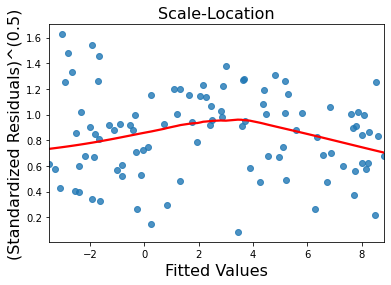

In [53]:
import seaborn as sns
p=sns.regplot(x=df['yhat'], y=np.sqrt(np.abs(df['std_res'])), lowess=True,line_kws={'color': 'red'})
p.set_title('Scale-Location', fontsize=16)
p.set_xlabel('Fitted Values', fontsize=16)
p.set_ylabel('(Standardized Residuals)^(0.5)', fontsize=16)

Text(0, 0.5, '(Standardized Residuals)^(0.5)')

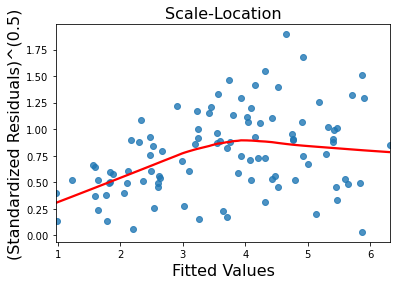

In [54]:
p=sns.regplot(x=df2['yhat'], y=np.sqrt(np.abs(df2['std_res'])), lowess=True,line_kws={'color': 'red'})
p.set_title('Scale-Location', fontsize=16)
p.set_xlabel('Fitted Values', fontsize=16)
p.set_ylabel('(Standardized Residuals)^(0.5)', fontsize=16)

Text(0, 0.5, '(Standardized Residuals)^(0.5)')

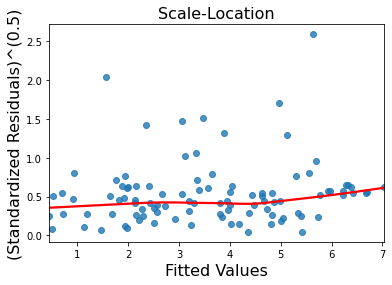

In [55]:
p=sns.regplot(x=df3['yhat'], y=np.sqrt(np.abs(df3['std_res'])), lowess=True,line_kws={'color': 'red'})
p.set_title('Scale-Location', fontsize=16)
p.set_xlabel('Fitted Values', fontsize=16)
p.set_ylabel('(Standardized Residuals)^(0.5)', fontsize=16)

Text(0, 0.5, '(Standardized Residuals)^(0.5)')

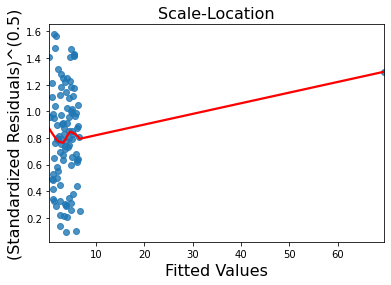

In [56]:
p=sns.regplot(x=df4['yhat'], y=np.sqrt(np.abs(df4['std_res'])), lowess=True,line_kws={'color': 'red'})
p.set_title('Scale-Location', fontsize=16)
p.set_xlabel('Fitted Values', fontsize=16)
p.set_ylabel('(Standardized Residuals)^(0.5)', fontsize=16)